In [29]:
# pandas for data manipulation
import pandas as pd
# seaborn + matplotlib for data visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
# sklearn for ml implementation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
import numpy as np
# pickle for saving model
import pickle

In [30]:
# read the dataset
df=pd.read_csv('dataset.csv', index_col=0)

In [31]:
df.head(10), df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

(                 track_id                               artists  \
 0  5SuOikwiRyPMVoIQDJUgSV                           Gen Hoshino   
 1  4qPNDBW1i3p13qLCt0Ki3A                          Ben Woodward   
 2  1iJBSr7s7jYXzM8EGcbK5b                Ingrid Michaelson;ZAYN   
 3  6lfxq3CG4xtTiEg7opyCyx                          Kina Grannis   
 4  5vjLSffimiIP26QG5WcN2K                      Chord Overstreet   
 5  01MVOl9KtVTNfFiBU9I7dc                          Tyrone Wells   
 6  6Vc5wAMmXdKIAM7WUoEb7N  A Great Big World;Christina Aguilera   
 7  1EzrEOXmMH3G43AXT1y7pA                            Jason Mraz   
 8  0IktbUcnAGrvD03AWnz3Q8             Jason Mraz;Colbie Caillat   
 9  7k9GuJYLp2AzqokyEdwEw2                        Ross Copperman   
 
                                           album_name  \
 0                                             Comedy   
 1                                   Ghost (Acoustic)   
 2                                     To Begin Again   
 3  Crazy Rich Asians 

In [32]:
print("Before dropna: ", df.shape)
df = df.dropna(axis=0)
print("After dropna: ", df.shape)
print("Number of unique elements: ", df['track_genre'].nunique())


Before dropna:  (114000, 20)
After dropna:  (113999, 20)
Number of unique elements:  114


It looks like this dataset has 114,000 entries with 20 columns/features. Some important features look like danceability, energy, loudness, and liveliness. There appears to be one null value artists, album_name, and track_name columns. Let's drop this null value. There are 114 unique genres in our dataset; we'll use these as a ground truth for labeling and classification later.

In [33]:
df["explicit"]=df["explicit"].astype(int) # convert explicit to int (1, 0)

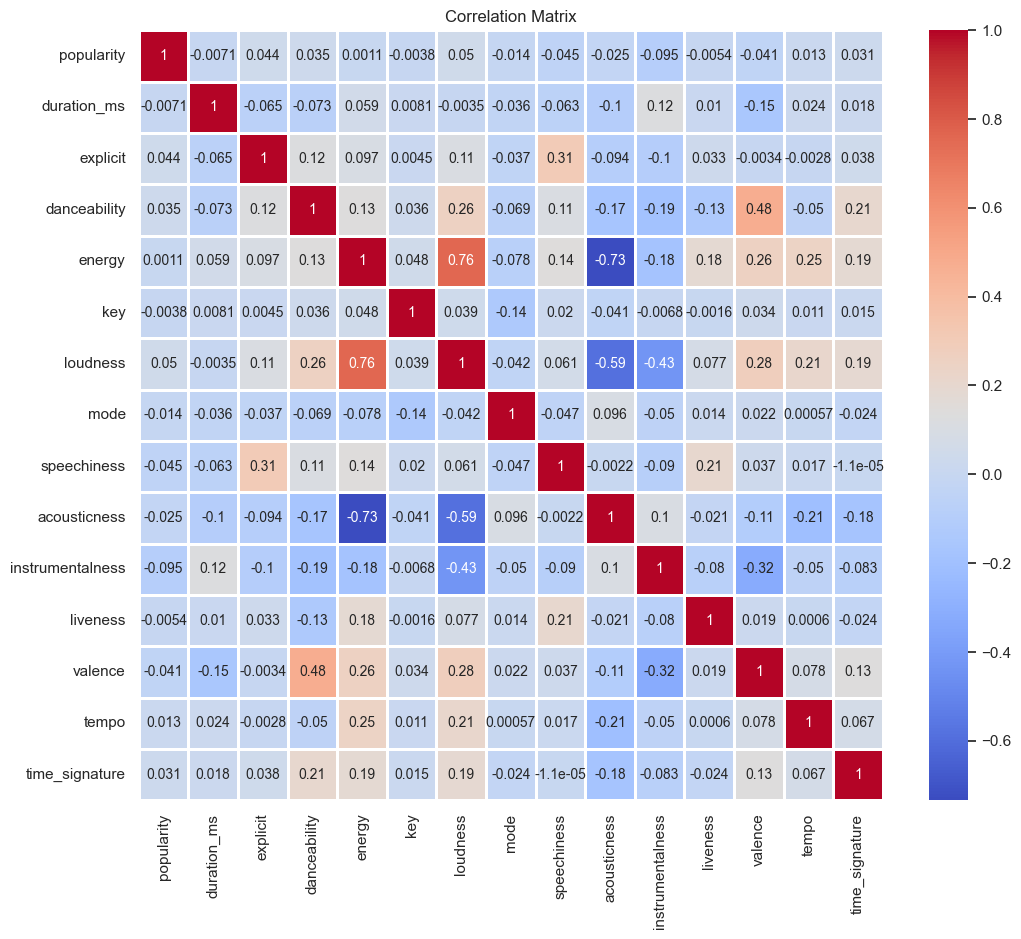

In [34]:
corr_mat = df.select_dtypes(include=["int", "float"]).corr()

plt.figure(figsize=(12, 10), facecolor='#FFF', edgecolor='black')
axes = plt.axes()
axes.set_facecolor('#FFF')
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', linewidths=1, annot_kws={"size": 10})
plt.title('Correlation Matrix')
plt.show()

- Strong Positive Correlation: Loudness and energy.
- Strong Negative Correlations: Acousticness with energy and acousticness with loudness.
- Negative Correlation: Instrumentalness and loudness.
- Weak Positive Correlations: Valence with danceability, and speechiness with explicit content.

In [35]:
# only numerical columns
num_cols = df[df.columns[(df.dtypes == 'float64') | (df.dtypes == 'int64')]]
num_cols.shape

(113999, 15)

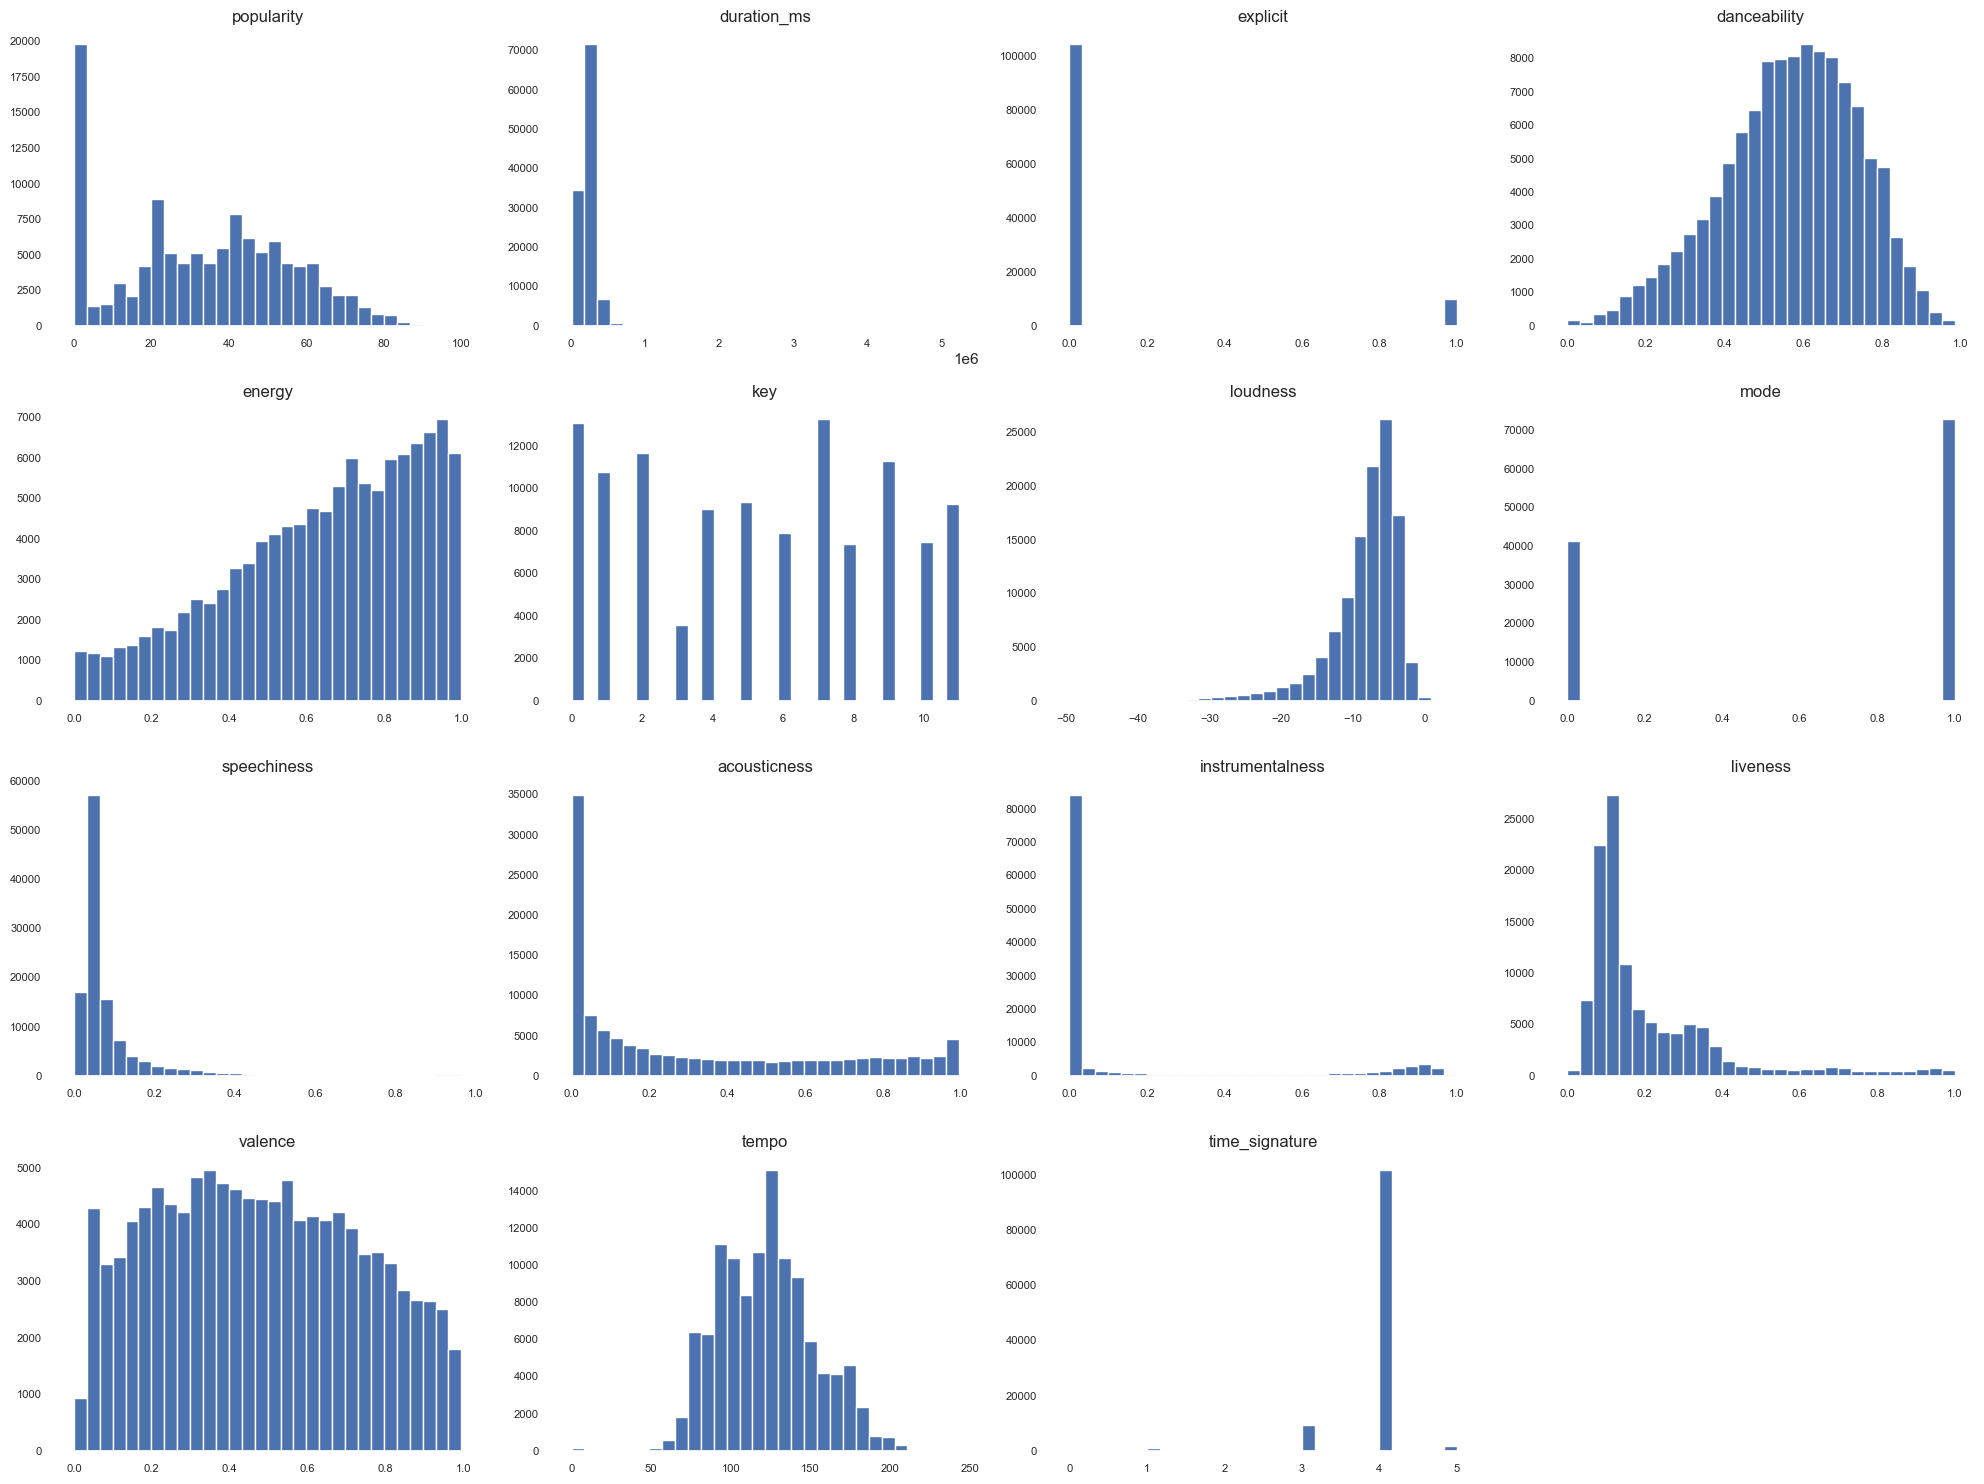

In [36]:
sns.set_style('whitegrid')
sns.set(rc={"axes.facecolor":"#FFF","figure.facecolor":"#FFF"})
num_cols.hist(figsize=(20,15), bins=30, xlabelsize=8, ylabelsize=8)
plt.tight_layout()
plt.show()

- Popularity: Right skewed, with most songs having low to moderate popularity.
- Duration: Concentrated in a low range, indicating shorter song lengths.
- Danceability: Roughly normal distribution centered around 0.6, indicating moderate to high danceability.
- Energy: Shows a positive slope, with more songs having higher energy levels.
- Key: Distribution is relatively uniform across different musical keys.
- Loudness: Heavily left skewed, with most songs being moderately loud.
- Speechiness: Right skewed, with most songs having low speech-like qualities.
- Acousticness: Slightly right skewed, suggesting a tendency towards less acoustic sounds.
- Liveness: Right skewed, indicating most songs are studio recordings rather than live performances.
- Tempo: Approximately normal distribution centered around 125 BPM.
- Time Signature: Mode is 4, which is standard in popular music.

# Goal
We want to develop predictive clustering model for genre aggregation and better suggestions. Better recommendation based on genre.

In [37]:
len(df['track_genre'].unique())

114

In [38]:
genre_to_category = {
    'edm': 'Electronic/Dance', 'electro': 'Electronic/Dance', 'house': 'Electronic/Dance',
    'trance': 'Electronic/Dance', 'techno': 'Electronic/Dance', 'dubstep': 'Electronic/Dance', 
    'drum-and-bass': 'Electronic/Dance', 'deep-house': 'Electronic/Dance', 'detroit-techno': 'Electronic/Dance', 
    'minimal-techno': 'Electronic/Dance', 'progressive-house': 'Electronic/Dance', 'breakbeat': 'Electronic/Dance',
    'chicago-house': 'Electronic/Dance', 'club': 'Electronic/Dance', 'idm': 'Electronic/Dance',
    'dance': 'Electronic/Dance', 'electronic': 'Electronic/Dance', 'trip-hop': 'Electronic/Dance', 
    
    'alt-rock': 'Rock/Metal', 'rock': 'Rock/Metal', 'punk': 'Rock/Metal', 'punk-rock': 'Rock/Metal',
    'hard-rock': 'Rock/Metal', 'metal': 'Rock/Metal', 'heavy-metal': 'Rock/Metal', 'black-metal': 'Rock/Metal', 
    'death-metal': 'Rock/Metal', 'grunge': 'Rock/Metal', 'garage': 'Rock/Metal', 'goth': 'Rock/Metal',
    'psych-rock': 'Rock/Metal', 'rock-n-roll': 'Rock/Metal', 'rockabilly': 'Rock/Metal', 'hardcore': 'Rock/Metal', 
    'metalcore': 'Rock/Metal', 'industrial': 'Rock/Metal', 'grindcore': 'Rock/Metal',
    
    'indie': 'Indie/Alternative', 'indie-pop': 'Indie/Alternative', 'emo': 'Indie/Alternative', 
    'alternative': 'Indie/Alternative', 'new-age': 'Indie/Alternative', 'psych-rock': 'Indie/Alternative',
    
    'hip-hop': 'Hip-Hop/Rap', 'trap': 'Hip-Hop/Rap', 'rap': 'Hip-Hop/Rap',
    
    'pop': 'Pop', 'electro-pop': 'Pop', 'synth-pop': 'Pop', 'k-pop': 'Pop', 'j-pop': 'Pop', 
    'pop-film': 'Pop', 'power-pop': 'Pop', 'british': 'Pop', 'cantopop': 'Pop', 'mandopop': 'Pop', 'j-idol': 'Pop',
    
    'r-n-b': 'R&B/Soul/Funk', 'soul': 'R&B/Soul/Funk', 'funk': 'R&B/Soul/Funk', 'gospel': 'R&B/Soul/Funk', 
    'blues': 'R&B/Soul/Funk', 'disco': 'R&B/Soul/Funk', 'groove': 'R&B/Soul/Funk',
    
    'jazz': 'Jazz/Blues', 'blues': 'Jazz/Blues', 'bluegrass': 'Jazz/Blues', 'swing': 'Jazz/Blues',
    
    'country': 'Country/Folk', 'folk': 'Country/Folk', 'singer-songwriter': 'Country/Folk', 'honky-tonk': 'Country/Folk',
    
    'classical': 'Classical/Instrumental', 'opera': 'Classical/Instrumental', 'piano': 'Classical/Instrumental', 
    'orchestral': 'Classical/Instrumental', 'instrumental': 'Classical/Instrumental',
    
    'latin': 'Latin/World', 'reggaeton': 'Latin/World', 'salsa': 'Latin/World', 'samba': 'Latin/World', 
    'reggae': 'Latin/World', 'dancehall': 'Latin/World', 'afrobeat': 'Latin/World', 'brazil': 'Latin/World', 
    'latino': 'Latin/World', 'forro': 'Latin/World', 'french': 'Latin/World', 'german': 'Latin/World', 
    'indian': 'Latin/World', 'iranian': 'Latin/World', 'turkish': 'Latin/World', 'swedish': 'Latin/World', 
    'j-dance': 'Latin/World', 'j-rock': 'Latin/World', 'spanish': 'Latin/World', 'malay': 'Latin/World', 
    'tango': 'Latin/World', 'world-music': 'Latin/World', 'pagode': 'Latin/World', 'mpb': 'Latin/World',
    
    'ambient': 'Ambient/Chill', 'chill': 'Ambient/Chill', 'study': 'Ambient/Chill', 'sleep': 'Ambient/Chill', 
    'new-age': 'Ambient/Chill', 'relax': 'Ambient/Chill', 'meditation': 'Ambient/Chill',
    
    'anime': 'Themed/Children', 'children': 'Themed/Children', 'comedy': 'Themed/Children', 
    'disney': 'Themed/Children', 'kids': 'Themed/Children', 'party': 'Themed/Children',
    
    'acoustic': 'Other', 'honky-tonk': 'Other', 'garage': 'Other', 'guitar': 'Other',
    'show-tunes': 'Other', 'songwriter': 'Other', 'happy': 'Other', 'dance-pop': 'Other',
    
    'sad': 'Mood', 'happy': 'Mood', 'romance': 'Mood', 'celebration': 'Mood'
}

df['music_category'] = df['track_genre'].apply(lambda x: genre_to_category.get(x, 'Other'))

# label_encoder = LabelEncoder()
# df['music_category_encoded'] = label_encoder.fit_transform(df['music_category'])

# df[['music_category', 'music_category_encoded']].head()

In [39]:
df.shape

(113999, 21)

In [40]:
df['music_category'].value_counts()

music_category
Latin/World               24000
Electronic/Dance          18000
Rock/Metal                17000
Other                     10000
Pop                        9999
Themed/Children            6000
R&B/Soul/Funk              6000
Indie/Alternative          5000
Ambient/Chill              5000
Jazz/Blues                 3000
Classical/Instrumental     3000
Country/Folk               3000
Mood                       3000
Hip-Hop/Rap                1000
Name: count, dtype: int64

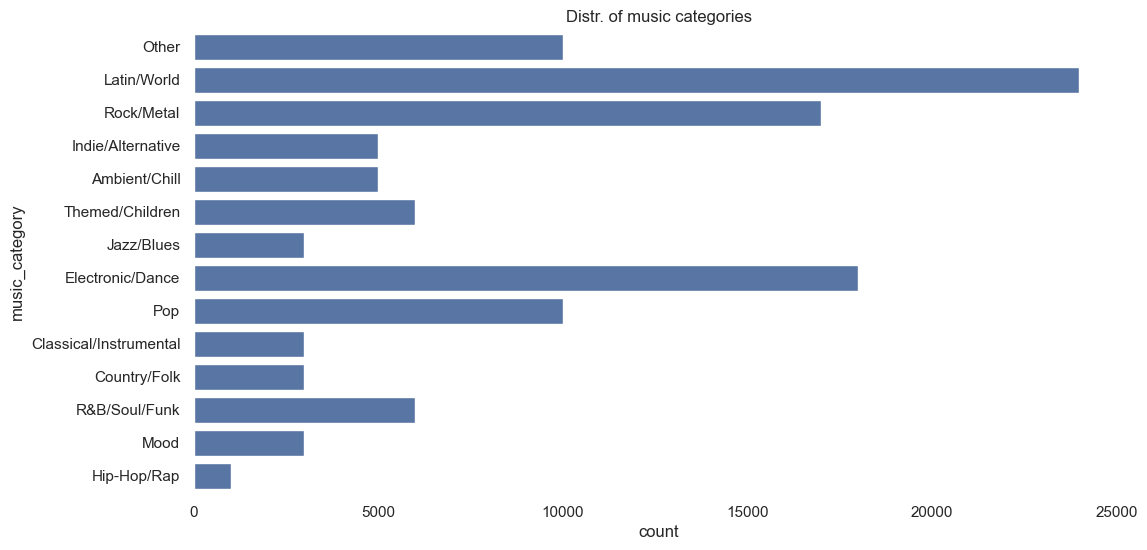

In [41]:
plt.figure(figsize=(12, 6))
sns.countplot(y='music_category', data=df, order=df['music_category'])
plt.title("Distr. of music categories")
plt.show()

In [42]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

music_category_encoded = encoder.fit_transform(df[['music_category']]).toarray()
encoded_df = pd.DataFrame(music_category_encoded, columns=encoder.get_feature_names_out(['music_category']))

df = pd.concat([df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

# df.drop('music_category', axis=1, inplace=True)

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,music_category_Hip-Hop/Rap,music_category_Indie/Alternative,music_category_Jazz/Blues,music_category_Latin/World,music_category_Mood,music_category_Other,music_category_Pop,music_category_R&B/Soul/Funk,music_category_Rock/Metal,music_category_Themed/Children
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [43]:
features = df[['danceability','energy', 'loudness', 'valence', 'tempo'] + list(encoded_df.columns)]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

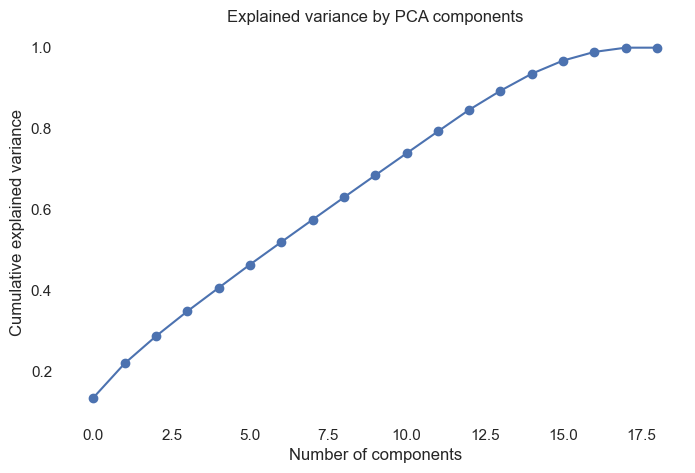

In [44]:
pca = PCA().fit(scaled_features)
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Explained variance by PCA components')
plt.show()

In [45]:
df = df.drop(columns=['time_signature', 'track_id', 'popularity', 'mode', 'explicit'])

In [46]:
df['music_category'].unique() 

array(['Other', 'Latin/World', 'Rock/Metal', 'Indie/Alternative',
       'Ambient/Chill', 'Themed/Children', 'Jazz/Blues',
       'Electronic/Dance', 'Pop', 'Classical/Instrumental',
       'Country/Folk', 'R&B/Soul/Funk', 'Mood', 'Hip-Hop/Rap'],
      dtype=object)

In [47]:
elbow_ss = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=100)
    kmeans.fit(scaled_features)
    elbow_ss.append(kmeans.inertia_)

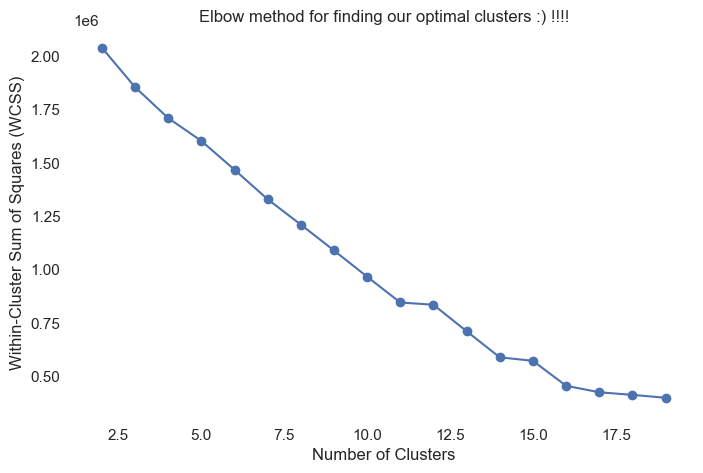

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 20), elbow_ss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow method for finding our optimal clusters :) !!!!')
plt.show()

In [49]:
kmeans = KMeans(n_clusters=14, random_state=100) 
df['cluster'] = kmeans.fit_predict(scaled_features)

In [50]:
pca = PCA(n_components=11, random_state=1)
reduced_features = pca.fit_transform(scaled_features)

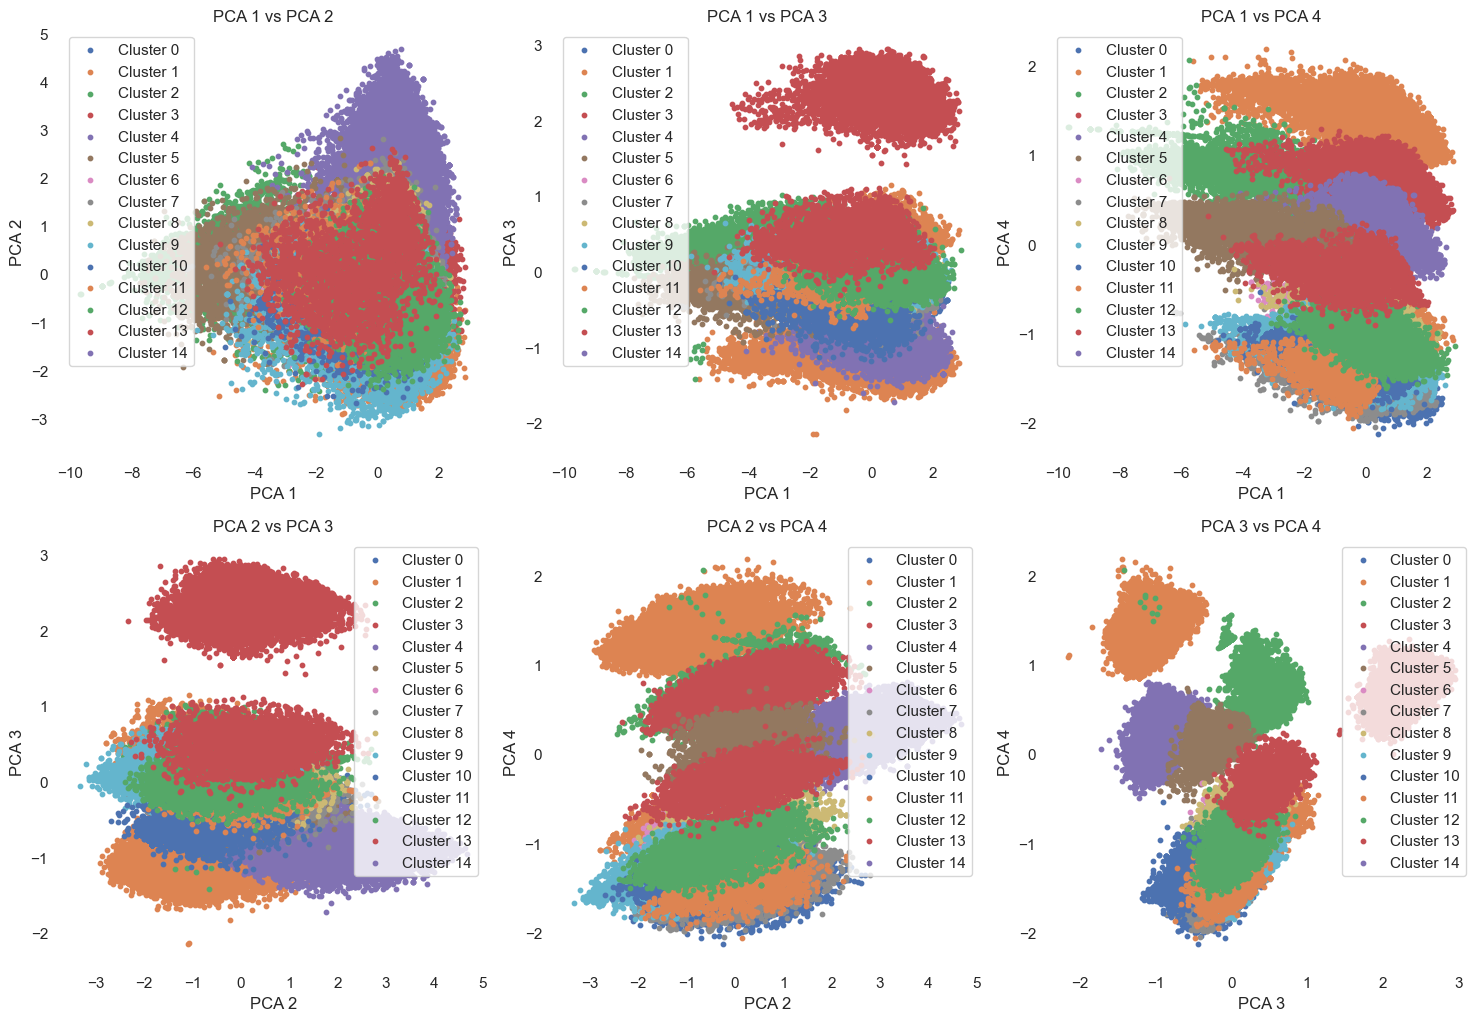

In [51]:
import itertools

n_components = 4
combinations = list(itertools.combinations(range(n_components), 2))

plt.figure(figsize=(15, 15))
for i, (x_idx, y_idx) in enumerate(combinations):
    plt.subplot(3, 3, i + 1)
    for cluster in range(15): 
        idx = df['cluster'] == cluster
        plt.scatter(reduced_features[idx, x_idx], reduced_features[idx, y_idx], 
                    label=f'Cluster {cluster}', s=10)
    plt.xlabel(f'PCA {x_idx + 1}')
    plt.ylabel(f'PCA {y_idx + 1}')
    plt.legend()
    plt.title(f'PCA {x_idx + 1} vs PCA {y_idx + 1}')
plt.tight_layout()
plt.show()

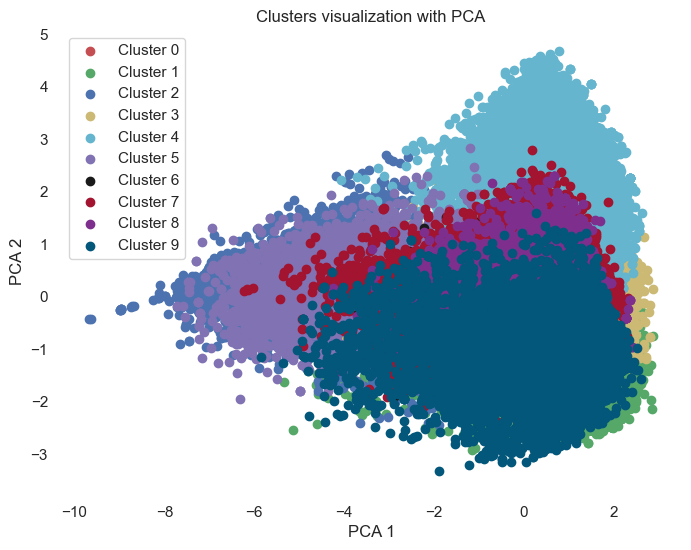

In [52]:
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b', 'y', 'c', 'm', 'k', '#A2142F', '#7E2F8E', '#02577a']  # Colors for the clusters

for i in range(10):
    idx = df['cluster'] == i

    plt.scatter(reduced_features[idx, 0], reduced_features[idx, 1], c=colors[i], label=f'Cluster {i}')
plt.title('Clusters visualization with PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

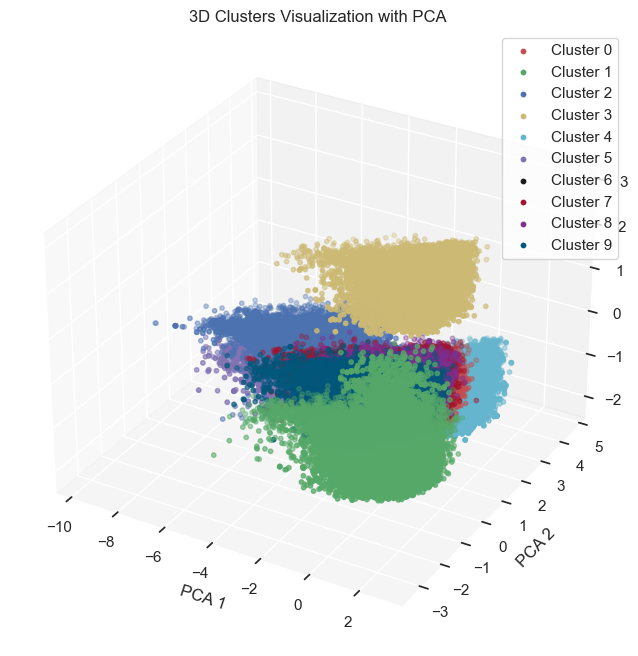

In [53]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(10):
    idx = df['cluster'] == i
    ax.scatter(reduced_features[idx, 0], reduced_features[idx, 1], reduced_features[idx, 2], 
               c=colors[i], label=f'Cluster {i}', s=10)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('3D Clusters Visualization with PCA')
ax.legend()
plt.show()

In [54]:
def most_common_wo_other(x):
    return x[x != 'Other'].value_counts().idxmax() if (x != 'Other').any() else 'Other'

cluster_mapping = df.groupby('cluster')['music_category'].agg(most_common_wo_other).to_dict()
print(cluster_mapping)
df['music_category'] = df['cluster'].map(cluster_mapping)

{0: 'Pop', 1: 'Latin/World', 2: 'Ambient/Chill', 3: 'Electronic/Dance', 4: 'Rock/Metal', 5: 'Classical/Instrumental', 6: 'Country/Folk', 7: 'Other', 8: 'Indie/Alternative', 9: 'Themed/Children', 10: 'Jazz/Blues', 11: 'Pop', 12: 'R&B/Soul/Funk', 13: 'Mood'}


In [55]:
df['music_category'].value_counts() # check clusters

music_category
Latin/World               24990
Electronic/Dance          18000
Rock/Metal                17000
Other                     10000
Pop                        9999
Themed/Children            6000
R&B/Soul/Funk              6000
Ambient/Chill              5010
Indie/Alternative          5000
Jazz/Blues                 3000
Classical/Instrumental     3000
Country/Folk               3000
Mood                       3000
Name: count, dtype: int64

In [56]:
df['cluster'].value_counts()

cluster
1     24990
3     18000
4     17000
7     10000
9      6000
12     6000
0      5804
2      5010
8      5000
11     4195
10     3000
5      3000
6      3000
13     3000
Name: count, dtype: int64

In [57]:
from sklearn.metrics import silhouette_score

labels = df['cluster']

sil_score = silhouette_score(scaled_features, labels)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.4521104255452636
